In [6]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
encoders = joblib.load("/content/label_encoders.pkl")

In [10]:
rf = joblib.load("/content/random_forest_model.pkl")

In [11]:
train_df = pd.read_parquet("/content/UNSW_NB15_training-set.parquet")

In [12]:
X_train = train_df.drop(columns=["label", "attack_cat"])

y_train = train_df["label"]

In [13]:
for col in ["proto", "service", "state"]:
    X_train[col] = encoders[col].transform(
        X_train[col]
    )

In [14]:
explainer = shap.TreeExplainer(rf)

In [15]:
sample = X_train.sample(
    100,
    random_state=42
)

In [16]:
shap_values = explainer.shap_values(sample)

In [19]:
import numpy as np
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(100, 34, 2)


In [21]:
shap_attack = shap_values[:, :, 1]

In [22]:
print(shap_attack.shape)

(100, 34)


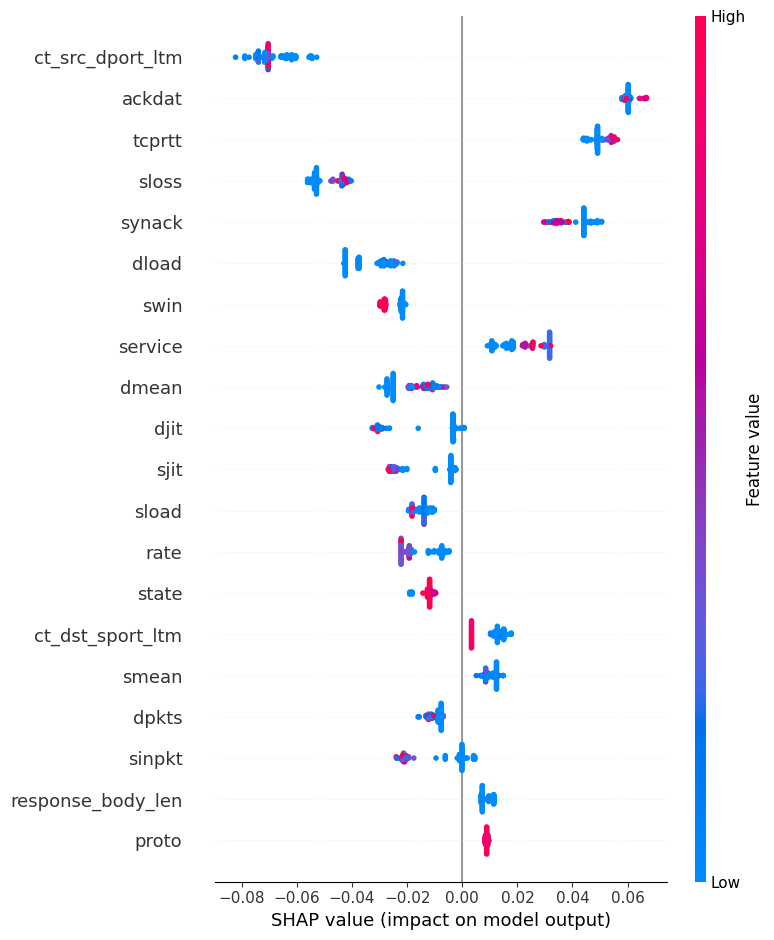

In [23]:
shap.summary_plot(
    shap_attack,
    sample
)

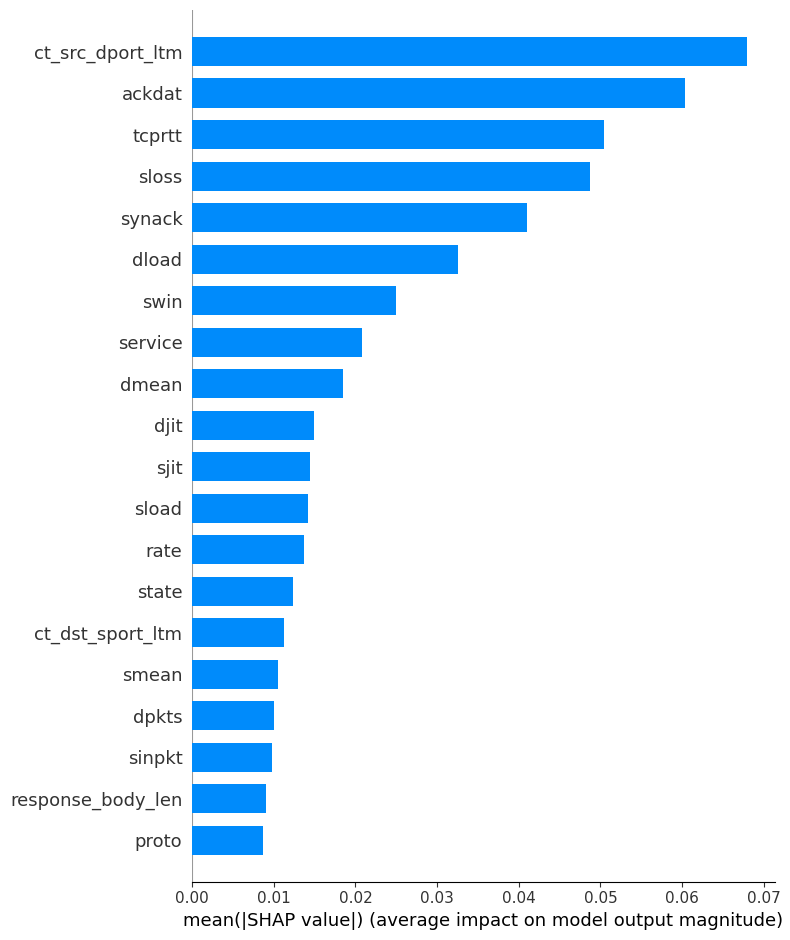

In [24]:
shap.summary_plot(
    shap_attack,
    sample,
    plot_type="bar"
)

In [25]:
sample.iloc[0]

,15482
dur,2.736664e+00
proto,1.130000e+02
service,0.000000e+00
state,4.000000e+00
spkts,2.320000e+02
dpkts,4.380000e+02
sbytes,1.335000e+04
dbytes,5.482160e+05
rate,2.444582e+02
sload,3.885899e+04


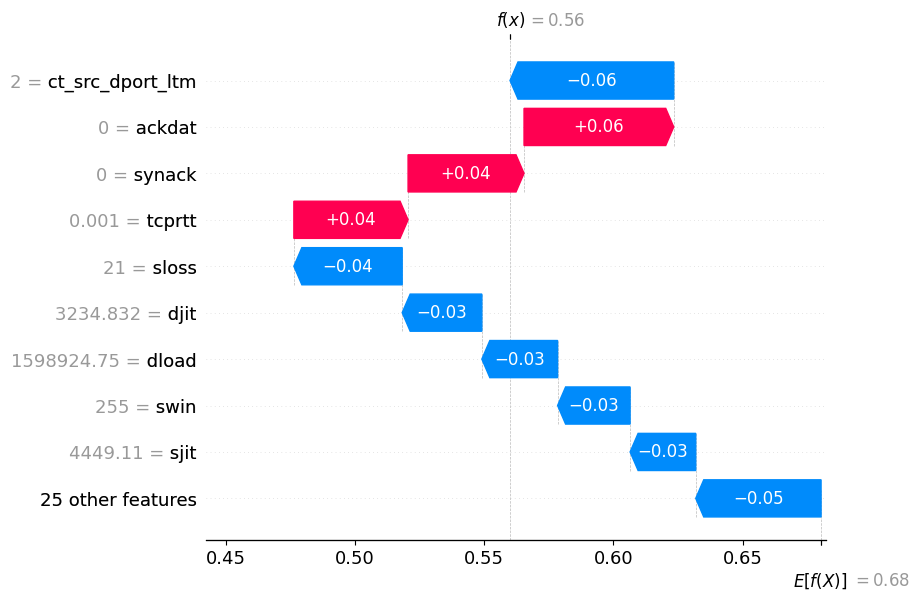

In [26]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_attack[0],
        base_values=explainer.expected_value[1],
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)